## Derivation of 10-state EKF

From AHRS (https://ahrs.readthedocs.io/en/latest/filters/ekf.html)

#### Prediction
We first use a 10-state vector, $x$, with a 4-state quaternion, 3-state position, and 3-state velocity. No drift/bias states.

$$\mathbf{x}_{t}=\begin{bmatrix}\mathbf{p}_{t} \\ \mathbf{v}_{t} \\ \mathbf{q}_{t} \end{bmatrix}$$

Quaternion Dynamics:
$$\begin{split}\begin{array}{rcl}
\hat{\mathbf{q}}_t &=& \mathbf{f}(\mathbf{q}_{t-1}, \boldsymbol\omega_t) \\
|&=&\Big(\mathbf{I}_4 + \frac{\Delta t}{2}\boldsymbol\Omega_t\Big)\mathbf{q}_{t-1} \\
\begin{bmatrix}\hat{q_w} \\ \hat{q_x} \\ \hat{q_y} \\ \hat{q_z}\end{bmatrix}
&=&
\begin{bmatrix}
    q_w - \frac{\Delta t}{2} \omega_x q_x - \frac{\Delta t}{2} \omega_y q_y - \frac{\Delta t}{2} \omega_z q_z\\
    q_x + \frac{\Delta t}{2} \omega_x q_w - \frac{\Delta t}{2} \omega_y q_z + \frac{\Delta t}{2} \omega_z q_y\\
    q_y + \frac{\Delta t}{2} \omega_x q_z + \frac{\Delta t}{2} \omega_y q_w - \frac{\Delta t}{2} \omega_z q_x\\
    q_z - \frac{\Delta t}{2} \omega_x q_y + \frac{\Delta t}{2} \omega_y q_x + \frac{\Delta t}{2} \omega_z q_w
\end{bmatrix}
\end{array}\end{split}$$
$$\mathbf{\Omega_{t}}=\begin{bmatrix}0 & -\mathbf{\omega} \\ \mathbf{\omega} & -\lfloor\omega\rfloor_{\times} \end{bmatrix}$$

Position and Velocity State Dynamics:
$$\hat{\mathbf{p}}_{t}=\mathbf{p}_{t-1} + \mathbf{v}_{t-1}\Delta{t} $$
$$\hat{\mathbf{v}}_{t}=\mathbf{v}_{t-1} + ({}^{I}\mathbf{R}_{B}{}^{B}\textbf{a}_{t-1}+\textbf{g})\Delta{t}$$

State Jacobian:
$$\begin{split}\begin{array}{rcl}
\mathbf{F}(\mathbf{x}_{t-1}, \boldsymbol\omega_t, \mathbf{a}_{t})
&=& \frac{\partial\mathbf{f}(\mathbf{x}_{t-1}, \boldsymbol\omega_t, \mathbf{a}_{t})}{\partial\mathbf{x}}
\end{array}\end{split}
$$

Process Noise Covariance (assuming isotropic noise):
$$\hat{\mathbf{P}}_t = \mathbf{F}(\mathbf{q}_{t-1}, \boldsymbol\omega_t)\mathbf{P}_{t-1}\mathbf{F}(\mathbf{q}_{t-1}, \boldsymbol\omega_t)^T + \mathbf{Q}_t$$
$$\begin{split}\begin{array}{rcl}
\mathbf{W}_t &=& \frac{\partial\mathbf{f}(\mathbf{q}_{t-1}, \boldsymbol\omega_t)}{\partial\boldsymbol\omega} \\
&=& \begin{bmatrix}
\frac{\partial\mathbf{f}(\mathbf{q}_{t-1}, \boldsymbol\omega_t)}{\partial\omega_x} &
\frac{\partial\mathbf{f}(\mathbf{q}_{t-1}, \boldsymbol\omega_t)}{\partial\omega_y} &
\frac{\partial\mathbf{f}(\mathbf{q}_{t-1}, \boldsymbol\omega_t)}{\partial\omega_z}
\end{bmatrix} \\
&=& \frac{\Delta t}{2}
\begin{bmatrix}
-q_x & -q_y & -q_z \\
q_w & -q_z & q_y \\
q_z & q_w & -q_x \\
-q_y & q_x & q_w
\end{bmatrix}
\end{array}\end{split}$$

$$\mathbf{Q}_t = \sigma_\boldsymbol\omega^2\mathbf{W}_t\mathbf{W}_t^T$$

Position and Velocity State Noise
$$\mathbf{Q}_p = \sigma_{a}\Delta{t}^{4}\mathbf{I}_{\text{3x3}}$$
$$\mathbf{Q}_v = \sigma_{a}\Delta{t}^{2}\mathbf{I}_{\text{3x3}}$$

We can improve upon this by using a coupled covariance model (and assuming istropic accelerometer noise):
$$Q_{pv}=\begin{bmatrix}Q_{p} & Q_{pv} \\ q_{pv} & q_{v}\end{bmatrix} = \begin{bmatrix}
\frac{\Delta{t}^{4}\mathbf{\sum_{a}}}{4} & \frac{\Delta{t}^{3}\mathbf{\sum_{a}}}{2} \\ \frac{\Delta{t}^{3}\mathbf{\sum_{a}}}{2} &
\Delta{t}^{2}\mathbf{\sum_{a}}\end{bmatrix}$$

The ESKF and filters with bias states can further improve by having a full coupled model that accounts for noise in the attitude estimate propogated by the gyrometer (see below).

#### Correction
$$\mathbf{x}_t = \hat{\mathbf{x}}_t + \mathbf{K}_t \big(\mathbf{z}_t - \mathbf{h}(\mathbf{x}_{t}))$$
$$\mathbf{P}_t = \hat{\mathbf{P}}_{t} - \mathbf{K}_{t}\mathbf{H}_{t}\mathbf{P}^{T}_{t}$$

Measurement Matrix:
$$\begin{split}\mathbf{z}_t =
\begin{bmatrix}\mathbf{a}_t \\ \mathbf{m}_t \\ \textbf{p}_{\text{gps}} \\ \textbf{v}_{\text{gps}} \\ z_{\text{baro}}\end{bmatrix}\end{split}$$

$$\mathbf{S}_{t}=\mathbf{H}\mathbf{\hat{P}_{t}}\mathbf{H}^{T}+\mathbf{R}$$
$$\mathbf{K}_{t}=\mathbf{\hat{P}_{t}}\mathbf{H}^{T}\mathbf{S}^{-1}_{t}$$

We split EKF fusion into four parts: accelerometer, magnetometer, GPS (position and velocity), and barometer.

H Matrix:
$$\mathbf{H}=\frac{\partial\mathbf{h}(\mathbf{x}_{t})}{\partial\mathbf{x}}$$
$$\begin{split}\begin{array}{rcl}
\mathbf{h}(\hat{\mathbf{x}}_t) &=& \begin{bmatrix}\hat{\mathbf{a}} \\
\hat{\mathbf{m}} \\ \hat{\mathbf{p}} \\ \hat{\mathbf{v}} \\ \hat{z} \end{bmatrix}
= \begin{bmatrix}\mathbf{C}(\hat{\mathbf{q}})^T \mathbf{g} \\ \mathbf{C}(\hat{\mathbf{q}})^T \mathbf{r} \\
\hat{\mathbf{p}} \\ \hat{\mathbf{v}} \\ \hat{z} \end{bmatrix}
\end{array}\end{split}$$

$\textbf{g}$ is the gravitational reference and $\textbf{r}$ is the magnetic field reference including inclination and declination.

R matrix - measurement covariance

The covariance for the accelerometer and magnetometer is quite straightforward as both sensors have isotropic and uncorrelated noise.

$$R_{\sigma_{a},\sigma_{m}}=\begin{bmatrix}\sigma_{a}\mathbf{I}_{3} & \mathbf{0}_{3} \\ \mathbf{0}_{3} & \sigma_{m}\mathbf{I}_{3}\end{bmatrix}$$

The GPS measurement noise is also dependent on the reported quality. For simulation, this will be constant for all axes.

The barometer noise is also independent and determined empirically.

In [3]:
import struct
import math
import time
import csv
import random

import casadi as ca
import numpy as np
from matplotlib import pyplot as plt

from scipy.spatial.transform import Rotation as R
from ahrs.common.orientation import acc2q
from ahrs import Quaternion

from scipy.signal import butter, filtfilt, lfilter, lfilter_zi

'''Read raw values'''
from parse import Parser
import random

import mc_common

parser = Parser()
mc_x, mc_y = parser.read_mincopter_log('../../build-generic/mincopter_log.txt')

print(list(mc_y.keys()))

## Injecting artificial noise
for i in range(0,len(mc_y['gyro_x'])):
    mc_y['gyro_x'][i] += random.gauss(sigma=0.1)
    mc_y['gyro_y'][i] += random.gauss(sigma=0.1)
    mc_y['gyro_z'][i] += random.gauss(sigma=0.1)
    
    mc_y['accel_x'][i] += random.gauss(sigma=0.1)
    mc_y['accel_y'][i] += random.gauss(sigma=0.1)
    mc_y['accel_z'][i] += random.gauss(sigma=0.1)


['roll', 'pitch', 'yaw', 'er_x', 'er_y', 'er_z', 'pos_x', 'pos_y', 'pos_z', 'vel_x', 'vel_y', 'vel_z', 'force', 'rt', 'pt', 'yt', 'm0', 'm1', 'm2', 'm3', 'accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z', 'comp_x', 'comp_y', 'comp_z', 'pos_x_a', 'pos_y_a', 'pos_z_a', 'vel_x_a', 'vel_y_a', 'vel_z_a', 'eul_x_a', 'eul_y_a', 'eul_z_a', 'er_x_a', 'er_y_a', 'er_z_a', 'gps_lat', 'gps_lng', 'gps_alt_cm', 'gps_vel_north', 'gps_vel_east', 'gps_vel_down', 'baro_pressure', 'baro_temperature', 'baro_alt_inferred']


In [4]:
## Common functions

def skew(v):
    '''Returns a skew-symmetric of a matrix'''
    return ca.vertcat(
        ca.horzcat(0, -v[2], v[1]),
        ca.horzcat(v[2], 0, -v[0]),
        ca.horzcat(-v[1], v[0], 0))

def to_rotation(q):
    return ca.vertcat(
        ca.horzcat(
            q[0]**2+q[1]**2-q[2]**2-q[3]**2,
            2*(q[1]*q[2]-q[0]*q[3]),
            2*(q[1]*q[3]+q[0]*q[2])),
        ca.horzcat(
            2*(q[1]*q[2]+q[0]*q[3]),
            q[0]*q[0]-q[1]*q[1]+q[2]*q[2]-q[3]*q[3],
            2*(q[2]*q[3]-q[0]*q[1])),
        ca.horzcat(
            2*(q[1]*q[3]-q[0]*q[2]),
            2*(q[0]*q[1]+q[2]*q[3]),
            q[0]*q[0]-q[1]*q[1]-q[2]*q[2]+q[3]*q[3]))

### EKF Model - 10-state, no drift states

In [5]:
def setup_ins_ekf():
    ''' The returned EKF requires parameters in the following format/units.

    q (4,1) - initial quaternion state estimate
    a_reading (3,1) - normalized accelerometer reading in ENU frame (stationary g vector would be [0 0 g])
    m_reading (3,1) - normalized magnetometer reading in ENU frame
    g_reading (3,1) - gyrometer reading in rad/s
    dt (1,1) - time elapsed since last reading/update
    gyro_var - gyrometer variance estimate
    accel_var - accelerometer variance estimate
    mag_var - magnetometer variance estimate

    '''

    ########################################
    ### 1. Prediction
    ########################################

    ## Symbolic variables - predict

    # Gyrometer reading and variance
    w = ca.SX.sym('w', 3, 1)
    gyro_var = ca.SX.sym('gvar')

    # Accelerometer reading
    a_reading = ca.SX.sym('a', 3, 1)
    accel_var = ca.SX.sym('avar')

    # Timestep
    dt = ca.SX.sym('dt')

    # Initial quaternion
    q = ca.SX.sym('q', 4, 1)
    p = ca.SX.sym('p', 10, 10)

    ## Position and velocity states
    x = ca.SX.sym('x', 3, 1)
    v = ca.SX.sym('v', 3, 1)

    # Calculate omega vec for attitude quaternion
    omega = ca.vertcat(
        ca.horzcat(0, -w.T),
        ca.horzcat(w, -skew(w)))

    # Calculate rotation matrix
    C_rot = to_rotation(q)

    # Calculate gravitational reference vector
    g_ref = ca.vertcat(0,0,-9.8)

    # State prediction using gyro and accelerometer readings
    state_f = ca.vertcat(
            x + v*dt,
            #v + (C_rot.T @ a_reading - g_ref)*dt,
            v + (C_rot @ a_reading - g_ref)*dt,
            (ca.SX_eye(4)+(dt/2)*omega) @ q
            )
    
    # 10-state matrix
    state_vec = ca.vertcat(x,v,q)

    ## Compute state jacobian
    state_jac = ca.jacobian(state_f, state_vec)
    if False:
        print(state_jac)

    ## State noise matrix
    xi_k = ca.vertcat(
            -(q[1:4]).T,
            q[0]*ca.SX_eye(3) + skew(q[1:4])
            )

    gy_noise = (-dt/2)*(xi_k @ ca.vertcat(ca.sqrt(gyro_var), ca.sqrt(gyro_var), ca.sqrt(gyro_var)) )
    noise_q = gyro_var*(gy_noise @ gy_noise.T)
    process_noise = ca.vertcat(
            ca.horzcat(accel_var*(dt**4)*ca.SX_eye(3), ca.SX.zeros(3,3), ca.SX.zeros(3,4)),
            ca.horzcat(ca.SX.zeros(3,3), accel_var*(dt**2)*ca.SX_eye(3), ca.SX.zeros(3,4)),
            ca.horzcat(ca.SX.zeros(4,3), ca.SX.zeros(4,3), noise_q)
            )

    # Estimation process covariance
    p_est = state_jac @ p @ state_jac.T + process_noise

    ''' Predict function

    Arguments:
        - dt : timestep in seconds since last predict call
        - w : gyrometer reading
        - a_reading : accelerometer reading
        - gyro_var : gyrometer noise
        - accel_var : accelerometer noise
        - p : covariance matrix
        - q : attitude quaternion (state)
        - x : position (state)
        - v : velocity (state)

    Returns:
        - state_f : Estimate of state
        - p_est   : Estimate of covariance matrix
    '''
    ekf_predict = ca.Function('ekf_predict', [dt, w, a_reading, gyro_var, accel_var, p, q, x, v], [state_f, p_est])

    ########################################
    ## 2. Correction
    ########################################

    # Predicted state vector (output from predict step, (x,v,q) )
    state_est = ca.SX.sym('state_estimate', 10, 1)
    
    # Predicted covariance vector (output from predict step)
    cov_est = ca.SX.sym('covariance_estimate', 10, 10)

    # Magnetometer reading and variance
    m_reading = ca.SX.sym('m', 3, 1)
    mag_var = ca.SX.sym('mvar')

    # GPS Position reading and variance
    gps_pos = ca.SX.sym('gps_x', 3, 1)
    gps_pos_var = ca.SX.sym('gps_xvar')

    # GPS Velocity reading and variance
    gps_vel = ca.SX.sym('gps_v', 3, 1)
    gps_vel_var = ca.SX.sym('gps_vvar')

    # Barometer reading and variance
    baro_z_pos = ca.SX.sym('baro_z_pos')
    baro_var = ca.SX.sym('baro_var')
    
    ### Magnetic field reference vector

    # Our magnetic field is in ENU frame.
    # We use 68deg as our magnetic field inclination and 12deg as declination
    _m0 = np.cos(12*np.pi/180)*np.cos(68*np.pi/180)
    _m1 = np.sin(12*np.pi/180)*np.cos(68*np.pi/180)
    _m2 = -np.sin(68*np.pi/180)
    _norm = np.linalg.norm([_m0, _m1, _m2])
    m_ref = ca.vertcat(_m0, _m1, _m2) / _norm

    # Compute rotation again
    est_C_rot = to_rotation(state_est[6:10])

    ## NOTE We compute four separate kalman gains
    
    ### Measurement matrix (estimated reference vectors in sensor frame)
    measurement = ca.vertcat(est_C_rot.T @ g_ref,
                             est_C_rot.T @ m_ref,
                             state_est[0:3], # position
                             state_est[3:6], # velocity
                             state_est[2])   # z-position

    ## Measurement jacobian (wrt state)
    measurement_jacobian = ca.jacobian(measurement, state_est)

    ## Measurement noise matrices
    m_noise_acc = accel_var*ca.SX_eye(3)
    m_noise_mag = mag_var*ca.SX_eye(3)
    m_noise_gps = ca.diagcat(
        gps_pos_var,
        gps_pos_var,
        gps_pos_var,
        gps_vel_var,
        gps_vel_var,
        gps_vel_var)
    m_noise_baro = baro_var*ca.SX_eye(1)
    
    ### Error between reference vector estimates (in sensor frame) and actual sensor readings
    vt_acc = a_reading - measurement[0:3]
    vt_mag = m_reading - measurement[3:6]
    vt_gps = ca.vertcat(gps_pos, gps_vel) - measurement[6:12]
    vt_baro = baro_z_pos - measurement[12]
    
    ### Compute Kalman gain
    st_acc = measurement_jacobian[0:3,:] @ cov_est @ measurement_jacobian[0:3,:].T + m_noise_acc
    st_mag = measurement_jacobian[3:6,:] @ cov_est @ measurement_jacobian[3:6,:].T + m_noise_mag
    st_gps = measurement_jacobian[6:12,:] @ cov_est @ measurement_jacobian[6:12,:].T + m_noise_gps
    st_baro = measurement_jacobian[12,:] @ cov_est @ measurement_jacobian[12,:].T + m_noise_baro
        
    ### Compute Kalman gain
    #st = measurement_jacobian @ cov_est @ measurement_jacobian.T + m_noise
    #kalman_gain = cov_est @ measurement_jacobian.T @ ca.inv(st)

    kt_acc = cov_est @ measurement_jacobian[0:3,:].T @ ca.inv(st_acc)
    kt_mag = cov_est @ measurement_jacobian[3:6,:].T @ ca.inv(st_mag)
    kt_gps = cov_est @ measurement_jacobian[6:12,:].T @ ca.inv(st_gps)
    kt_baro = cov_est @ measurement_jacobian[12,:].T @ ca.inv(st_baro)

    '''The following fusion functions return:
    - state
    - covariance
    - vt (error term)
    - kt (kalman gain)

    '''
    
    ## Accelerometer fusion
    '''a_reading (3,)
    accel_var (1,)
    state_est (16,16)
    cov_est (16,16)'''
    ekf_fuse_acc = ca.Function('ekf_fuse_acc',
                               [a_reading, accel_var, state_est, cov_est],
                               [state_est + kt_acc @ vt_acc, cov_est - kt_acc @ measurement_jacobian[0:3,:] @ cov_est, vt_acc, kt_acc])

    '''m_reading (3,)
    mag_var (1,)
    state_est (16,16)
    cov_est (16,16)'''
    ekf_fuse_mag = ca.Function('ekf_fuse_mag',
                               [m_reading, mag_var, state_est, cov_est],
                               [state_est + kt_mag @ vt_mag, cov_est - kt_mag @ measurement_jacobian[3:6,:] @ cov_est, vt_mag, kt_mag])

    '''gps_pos (3,)
    gps_vel (3,)
    gps_pos_var (1,)
    gps_vel_var (1,)
    state_est (16,16)
    cov_est (16,16)'''
    ekf_fuse_gps = ca.Function('ekf_fuse_gps',
                               [gps_pos, gps_vel, gps_pos_var, gps_vel_var, state_est, cov_est],
                               [state_est + kt_gps @ vt_gps, cov_est - kt_gps @ measurement_jacobian[6:12,:] @ cov_est, vt_gps, kt_gps])

    '''baro_z_pos (1,)
    baro_var (1,)
    state_est (16,16)
    cov_est (16,16)'''
    ekf_fuse_baro = ca.Function('ekf_fuse_baro',
                                [baro_z_pos, baro_var, state_est, cov_est],
                                [state_est + kt_baro @ vt_baro, cov_est - kt_baro @ measurement_jacobian[12,:] @ cov_est, vt_baro, kt_baro])


    ## The following are the function signatures of each of the EKF fusion functions
    ## They will also be converted to casadi c-functions by the .generate method. This is the interface by which they are created and
    ## added to MinCopter
    
    ### Apply the Kalman gain to estimate the (corrected) state

    ''' Correct step

    Arguments:
        - state_est : Estimated state from the predict step
        - cov_est   : Estimated covariance matrix from the predict step
        - a_reading : Accelerometer reading
        - accel_var : Accelerometer noise
        - m_reading : Magnetometer reading
        - mag_var   : Magnetometer noise
        - gps_pos   : GPS Position measurement
        - gps_vel   : GPS Velocity measurement
        - gps_pos_var : GPS position noise
        - gps_vel_var : GPS velocity noise

    Returns:
        - state_out   : Corrected state estimate
        - p_out       : Corrected covariance esetimate
        - vt          : Error term in state update
        - kalman_gain : Kalman gain applied to error term
    '''
    '''
    ekf_correct = ca.Function('ekf_correct',
                      [state_est, cov_est, a_reading, accel_var, m_reading, mag_var, gps_pos, gps_vel, gps_pos_var, gps_vel_var],
                      [state_out, p_out, vt, kalman_gain]
                      )
    '''

    if True:
        ekf_predict.generate('ekf_predict_10state.c')
        ekf_fuse_acc.generate('ekf_fuse_acc_10state.c')
        ekf_fuse_mag.generate('ekf_fuse_mag_10state.c')
        ekf_fuse_gps.generate('ekf_fuse_gps_10state.c')
        ekf_fuse_baro.generate('ekf_fuse_baro_10state.c')

    return (ekf_predict, ekf_fuse_acc, ekf_fuse_mag, ekf_fuse_gps, ekf_fuse_baro)

    

### EKF Model - 16-state (pos, vel, quat, drift states)

In [6]:
def setup_ekf_16():
    
    # Gyrometer
    w = ca.SX.sym('w', 3, 1)
    gyro_var = ca.SX.sym('gvar')

    # Accelerometer
    a_reading = ca.SX.sym('a', 3, 1)
    accel_var = ca.SX.sym('avar')

    # Accelerometer and Gyrometer Drift Variances (used for drift states)
    a_drift_var = ca.SX.sym('a_drift_var')
    q_drift_var = ca.SX.sym('q_drift_var')
    
    # Timestep
    dt = ca.SX.sym('dt')

    ## States
    x = ca.SX.sym('x', 3, 1)
    v = ca.SX.sym('v', 3, 1)
    q = ca.SX.sym('q', 4, 1)
    q_bias = ca.SX.sym('q_bias', 3, 1)
    a_bias = ca.SX.sym('x_bias', 3, 1)

    state_vec = ca.vertcat(x,v,q, q_bias, a_bias)

    ## State Covariance
    p = ca.SX.sym('p', 16, 16)

    ### 1. State Dynamics
    
    # Calculate omega vec for attitude quaternion
    omega = ca.vertcat(
        ca.horzcat(0, -w.T),
        ca.horzcat(w, -skew(w)))

    omega_bias = ca.vertcat(
        ca.horzcat(0, -q_bias.T),
        ca.horzcat(q_bias, -skew(q_bias)))

    # Calculate rotation matrix
    C_rot = to_rotation(q)

    # Calculate gravitational reference vector
    g_ref = ca.vertcat(0,0,-9.8)

    state_f = ca.vertcat(
        x + v*dt,
        v + (C_rot @ (a_reading - a_bias) - g_ref)*dt,
        (ca.SX_eye(4)+(dt/2)*(omega - omega_bias)) @ q,
        q_bias,
        a_bias)
    

    ## Compute state jacobian
    state_jac = ca.jacobian(state_f, state_vec)
    if False:
        print(state_jac)

    ### 2. Process Noise Covariance

    ## Construction of Q, Process Noise Covariance Matrix (16x16)
    xi_k = (-dt/2)*ca.vertcat(
            -(q[1:4]).T,
            q[0]*ca.SX_eye(3) + skew(q[1:4])
            )

    noise_q = gyro_var*(xi_k @ xi_k.T)

    '''
    0:3 position covariance
    3:6 velocity covariance
    6:10 quaternion covariance
    10:13 quaternion bias
    13:16 accel bias
    '''
    
    process_noise = ca.blockcat([
        [accel_var*(dt**4)*ca.SX_eye(3), ca.SX.zeros(3,13)],
        [ca.SX.zeros(3,3), accel_var*(dt**2)*ca.SX_eye(3), ca.SX.zeros(3,10)],
        [ca.SX.zeros(4,6), noise_q, ca.SX.zeros(4,6)],
        [ca.SX.zeros(3,10), a_drift_var*ca.SX_eye(3), ca.SX.zeros(3,3)],
        [ca.SX.zeros(3,13), q_drift_var*ca.SX_eye(3)]
    ])

    ## Calculate P matrix
    p_est = state_jac @ p @ state_jac.T + process_noise

    ekf_predict = ca.Function('ekf_predict', [dt, w, a_reading, gyro_var, accel_var, p, q, x, v, q_bias, a_bias, a_drift_var, q_drift_var],
                              [state_f, p_est])

    ## 2. Correction
    
    # Predicted state vector (output from predict step, (x,v,q) )
    state_est = ca.SX.sym('state_estimate', 16, 1)
    
    # Predicted covariance vector (output from predict step)
    cov_est = ca.SX.sym('covariance_estimate', 16, 16)

    # Magnetometer reading and variance
    m_reading = ca.SX.sym('m', 3, 1)
    mag_var = ca.SX.sym('mvar')

    # GPS Position reading and variance
    gps_pos = ca.SX.sym('gps_x', 3, 1)
    gps_pos_var = ca.SX.sym('gps_xvar')

    # GPS Velocity reading and variance
    gps_vel = ca.SX.sym('gps_v', 3, 1)
    gps_vel_var = ca.SX.sym('gps_vvar')

    # Barometer reading and variance
    baro_z_pos = ca.SX.sym('baro_z_pos')
    baro_var = ca.SX.sym('baro_var')
    
    ### Magnetic field reference vector

    # Our magnetic field is in ENU frame.
    # We use 68deg as our magnetic field inclination and 12deg as declination
    _m0 = np.cos(12*np.pi/180)*np.cos(68*np.pi/180)
    _m1 = np.sin(12*np.pi/180)*np.cos(68*np.pi/180)
    _m2 = -np.sin(68*np.pi/180)
    _norm = np.linalg.norm([_m0, _m1, _m2])
    m_ref = ca.vertcat(_m0, _m1, _m2) / _norm

    # Compute rotation again
    est_C_rot = to_rotation(state_est[6:10])

    ## NOTE We compute four separate kalman gains
    
    ### Measurement matrix (estimated reference vectors in sensor frame)
    measurement = ca.vertcat(est_C_rot.T @ g_ref,
                             est_C_rot.T @ m_ref,
                             state_est[0:3], # position
                             state_est[3:6], # velocity
                             state_est[2])   # z-position

    ## Measurement jacobian (wrt state)
    measurement_jacobian = ca.jacobian(measurement, state_est)

    ## Measurement noise matrices
    m_noise_acc = accel_var*ca.SX_eye(3)
    m_noise_mag = mag_var*ca.SX_eye(3)
    m_noise_gps = ca.diagcat(
        gps_pos_var,
        gps_pos_var,
        gps_pos_var,
        gps_vel_var,
        gps_vel_var,
        gps_vel_var)
    m_noise_baro = baro_var*ca.SX_eye(1)
    
    ### Error between reference vector estimates (in sensor frame) and actual sensor readings
    vt_acc = a_reading - measurement[0:3]
    vt_mag = m_reading - measurement[3:6]
    vt_gps = ca.vertcat(gps_pos, gps_vel) - measurement[6:12]
    vt_baro = baro_z_pos - measurement[12]
    
    ### Compute Kalman gain
    st_acc = measurement_jacobian[0:3,:] @ cov_est @ measurement_jacobian[0:3,:].T + m_noise_acc
    st_mag = measurement_jacobian[3:6,:] @ cov_est @ measurement_jacobian[3:6,:].T + m_noise_mag
    st_gps = measurement_jacobian[6:12,:] @ cov_est @ measurement_jacobian[6:12,:].T + m_noise_gps
    st_baro = measurement_jacobian[12,:] @ cov_est @ measurement_jacobian[12,:].T + m_noise_baro
        
    ### Compute Kalman gain
    #st = measurement_jacobian @ cov_est @ measurement_jacobian.T + m_noise
    #kalman_gain = cov_est @ measurement_jacobian.T @ ca.inv(st)

    kt_acc = cov_est @ measurement_jacobian[0:3,:].T @ ca.inv(st_acc)
    kt_mag = cov_est @ measurement_jacobian[3:6,:].T @ ca.inv(st_mag)
    kt_gps = cov_est @ measurement_jacobian[6:12,:].T @ ca.inv(st_gps)
    kt_baro = cov_est @ measurement_jacobian[12,:].T @ ca.inv(st_baro)

    '''The following fusion functions return:
    - state
    - covariance
    - vt (error term)
    - kt (kalman gain)

    '''
    
    ## Accelerometer fusion
    ekf_fuse_acc = ca.Function('ekf_fuse_acc',
                               [a_reading, accel_var, state_est, cov_est],
                               [state_est + kt_acc @ vt_acc, cov_est - kt_acc @ measurement_jacobian[0:3,:] @ cov_est, vt_acc, kt_acc])

    ekf_fuse_mag = ca.Function('ekf_fuse_mag',
                               [m_reading, mag_var, state_est, cov_est],
                               [state_est + kt_mag @ vt_mag, cov_est - kt_mag @ measurement_jacobian[3:6,:] @ cov_est, vt_mag, kt_mag])

    ekf_fuse_gps = ca.Function('ekf_fuse_gps',
                               [gps_pos, gps_vel, gps_pos_var, gps_vel_var, state_est, cov_est],
                               [state_est + kt_gps @ vt_gps, cov_est - kt_gps @ measurement_jacobian[6:12,:] @ cov_est, vt_gps, kt_gps])

    ekf_fuse_baro = ca.Function('ekf_fuse_baro',
                                [baro_z_pos, baro_var, state_est, cov_est],
                                [state_est + kt_baro @ vt_baro, cov_est - kt_baro @ measurement_jacobian[12,:] @ cov_est, vt_baro, kt_baro])
                               
    ### Apply the Kalman gain to estimate the (corrected) state

    ''' Correct step

    Arguments:
        - state_est : Estimated state from the predict step
        - cov_est   : Estimated covariance matrix from the predict step
        - a_reading : Accelerometer reading
        - accel_var : Accelerometer noise
        - m_reading : Magnetometer reading
        - mag_var   : Magnetometer noise
        - gps_pos   : GPS Position measurement
        - gps_vel   : GPS Velocity measurement
        - gps_pos_var : GPS position noise
        - gps_vel_var : GPS velocity noise

    Returns:
        - state_out   : Corrected state estimate
        - p_out       : Corrected covariance esetimate
        - vt          : Error term in state update
        - kalman_gain : Kalman gain applied to error term
    '''
    '''
    ekf_correct = ca.Function('ekf_correct',
                      [state_est, cov_est, a_reading, accel_var, m_reading, mag_var, gps_pos, gps_vel, gps_pos_var, gps_vel_var],
                      [state_out, p_out, vt, kalman_gain]
                      )
    '''

    if True:
        ekf_predict.generate('ekf_predict_16state.c')
        ekf_fuse_acc.generate('ekf_fuse_acc_16state.c')
        ekf_fuse_mag.generate('ekf_fuse_mag_16state.c')
        ekf_fuse_gps.generate('ekf_fuse_gps_16state.c')
        ekf_fuse_baro.generate('ekf_fuse_baro_16state.c')

    return (ekf_predict, ekf_fuse_acc, ekf_fuse_mag, ekf_fuse_gps, ekf_fuse_baro)

    

In [7]:
use_16_ekf = False

def run_full_ekf(variances, flags):
    '''Runs the full EKF state estimation for the parsed sensor readings (via ctx, which is global now but should passed in as a param later)
    
    Args:
    - variances: Dict of variances that we want to use'''

    iterations = len(mc_y['roll'])-100

    ## ekf_state does not contain the quaternion but rather the euler angles, giving it the form (roll,pitch,yaw, posx, posy, posx, velx, vely, velz)
    ekf_vals = {
        'ekf_state': np.zeros((15, iterations)),
        'ekf_vt_acc': np.zeros((3, iterations)),
        'ekf_vt_mag': np.zeros((3, iterations)),
        'ekf_vt_gps': np.zeros((6, iterations)),
        'ekf_vt_baro': np.zeros((1, iterations)),
        'ekf_cov': np.zeros((16,16,iterations)) if use_16_ekf else np.zeros((10,10,iterations))
    }
    
    ## Initialise EKF
    if use_16_ekf:
        ekf_predict, ekf_fuse_acc, ekf_fuse_mag, ekf_fuse_gps, ekf_fuse_baro = setup_ekf_16()
    else:
        ekf_predict, ekf_fuse_acc, ekf_fuse_mag, ekf_fuse_gps, ekf_fuse_baro = setup_ins_ekf()

    ## Initial Quaternion state is no rotation and directly up (which is -ve in NED frame). Pos & vel are stationary
    q_next = [-1.0, 0.0, 0.0, 0.0]
    x_next = np.array([0,0,0], dtype=np.float64).reshape((3,))
    v_next = np.array([0,0,0], dtype=np.float64).reshape((3,))

    if use_16_ekf:
        p_next = np.eye(16)
    else:
        p_next = np.eye(10)

    q_bias_next = np.array([0,0,0], dtype=np.float64).reshape((3,))
    a_bias_next = np.array([0,0,0], dtype=np.float64).reshape((3,))

    ''' These give reasonably good response but'''
    #gvar = 0.01**2
    #avar = 1e2**2
    #avar_norm = 1e2**2
    #mvar = 0.01**2
        
    gvar = variances['gvar']
    avar = variances['avar']
    mvar = variances['mvar']
    gps_pvar = variances['gps_pvar']
    gps_vvar = variances['gps_vvar']
    baro_var = variances['baro_var']

    ## Get home position as first non-zero GPS lat/lon
    home_lat = None
    home_lng = None
    for e in mc_y['gps_lat']:
        if e != 0:
            home_lat = e
            break
    for e in mc_y['gps_lng']:
        if e != 0:
            home_lng = e
            break

    baro_ground_pressure = None
    baro_ground_temperature = None
    for e in mc_y['baro_pressure']:
        if e!=0.0:
            baro_ground_pressure = e
            break
    for e in mc_y['baro_temperature']:
        if e!=0.0:
            baro_ground_temperature = e
            break
            
    print(f"Home lat/lon set as ({home_lat}, {home_lng})")
    print(f"Ground press/temp set as ({baro_ground_pressure}, {baro_ground_temperature})")

    for i in range(0,iterations):
        
        ## 1. Normalise accelerometer data, however in the predict step we integrate the actual accelerometer (corrected for gravity)

        ## For the correction, we actually filter the acceleration vector
        #_a_norm = math.sqrt(ax_filt[i*10]**2 + ay_filt[i*10]**2 + az_filt[i*10]**2)
        _a_norm = math.sqrt(mc_y['accel_x'][i]**2 + mc_y['accel_y'][i]**2 + mc_y['accel_z'][i]**2)        
        
        _a_norm_x = mc_y['accel_x'][i] / ( _a_norm if _a_norm!=0 else 1)
        _a_norm_y = mc_y['accel_y'][i] / ( _a_norm if _a_norm!=0 else 1)
        _a_norm_z = mc_y['accel_z'][i] / ( _a_norm if _a_norm!=0 else 1)
            
        ## 2. Offset magnetometer data
        # NOTE Don't need for simulated data + should already be done in dev/AP_Compass class
        
        ## 4. Normalise magnetometer data
        _m_norm = math.sqrt(mc_y['comp_x'][i]**2 + mc_y['comp_y'][i]**2 + mc_y['comp_z'][i]**2)
        mc_y['comp_x'][i] /= (_m_norm if _m_norm!=0 else 1)
        mc_y['comp_y'][i] /= (_m_norm if _m_norm!=0 else 1)
        mc_y['comp_z'][i] /= (_m_norm if _m_norm!=0 else 1)
        
        ## Convert GPS latitude, longitude, altitude to position
        gps_pos = mc_common.gps_to_pos(mc_y['gps_lat'][i], mc_y['gps_lng'][i], mc_y['gps_alt_cm'][i], home_lat, home_lng, 0)

        ## Get GPS NED velocity directly from reading
        gps_vel = np.array([0,0,0], dtype=np.float64).reshape(3,1)
        gps_vel[0] = mc_y['gps_vel_north'][i]
        gps_vel[1] = mc_y['gps_vel_east'][i]
        gps_vel[2] = mc_y['gps_vel_down'][i]
        
        baro_alt = mc_common.baro_press_temp_to_alt(mc_y['baro_pressure'][i],
                                                    mc_y['baro_temperature'][i],
                                                    baro_ground_pressure,
                                                    baro_ground_temperature)

        ## If we are accelerating, then don't use the accelerometer vector for roll/pitch correctino
        '''
        if abs(_a_norm - 9.8) > 0.5:
            flags['fuse_acc'] = False
        else:
            flags['fuse_acc'] = True
        '''
            
        ## Run the full EKF update
        if True:
            ## TODO
            kgain = None
            
            ## Predict
            if use_16_ekf:
                state_out, cov_out = ekf_predict(
                        0.01,
                        np.array([mc_y['gyro_x'][i], mc_y['gyro_y'][i], mc_y['gyro_z'][i]]),
                        np.array([mc_y['accel_x'][i], mc_y['accel_y'][i], mc_y['accel_z'][i]]),
                        avar, ## Accel var
                        p_next,
                        q_next,
                        x_next,
                        v_next,
                        q_bias_next,
                        a_bias_next,
                        variances['q_drift_var'],
                        variances['a_drift_var'])               
                    
            else:
                state_out, cov_out = ekf_predict(
                        0.01,
                        np.array([mc_y['gyro_x'][i], mc_y['gyro_y'][i], mc_y['gyro_z'][i]]),
                        np.array([mc_y['accel_x'][i], mc_y['accel_y'][i], mc_y['accel_z'][i]]),
                        gvar, ## Gyro var
                        avar, ## Accel var
                        p_next,
                        q_next,
                        x_next,
                        v_next)

            ## Fusion/Correction

            ## 1. Accelerometer fusion
            if (flags['fuse_acc']):
                state_out, cov_out, vt, kgain = ekf_fuse_acc(
                    #np.array([mc_y['accel_x'][i], mc_y['accel_y'][i], mc_y['accel_z'][i]]),
                    np.array([_a_norm_x, _a_norm_y, _a_norm_z]),
                    avar,
                    state_out,
                    cov_out)
                ekf_vals['ekf_vt_acc'][:,i] = vt.full().reshape(-1)

            ## 2. Magnetometer fusion (20Hz)
            if (flags['fuse_mag']) and i%5==0:
                state_out, cov_out, vt, kgain = ekf_fuse_mag(
                    np.array([mc_y['comp_x'][i], mc_y['comp_y'][i], mc_y['comp_z'][i]]),
                    mvar,
                    state_out,
                    cov_out)
                ekf_vals['ekf_vt_mag'][:,i] = vt.full().reshape(-1)

            ## 3. GPS fusion (5Hz)
            if (flags['fuse_gps'] and i%100==0):
                state_out, cov_out, vt, kgain = ekf_fuse_gps(
                    gps_pos,
                    gps_vel,
                    gps_pvar,
                    gps_vvar,
                    state_out,
                    cov_out)
                ekf_vals['ekf_vt_gps'][:,i] = vt.full().reshape(-1)

            ## 4. Baro fusion
            if (flags['fuse_baro']):
                state_out, cov_out, vt, kgain = ekf_fuse_baro(
                    baro_alt,
                    baro_var,
                    state_out,
                    cov_out)
                ekf_vals['ekf_vt_baro'][:,i] = vt.full().reshape(-1)
            
            ## Extract actual states from state vector
            state = state_out.full()

            ## NOTE State vector is in (x,v,q) format
            x_next = state_out[0:3].full()
            v_next = state_out[3:6].full()
            q_next = state_out[6:10].full()

            if use_16_ekf:
                q_bias_next = state_out[10:13].full()
                a_bias_next = state_out[13:16].full()

            ekf_vals['ekf_cov'][:,:,i] = cov_out.full()

        ## Normalise output quaternion
        _q_norm = np.linalg.norm(q_next)
        q_next = q_next / _q_norm

        temp_eul = Quaternion(q_next.reshape(-1)).to_angles()

        ekf_vals['ekf_state'][0:3, i] = temp_eul
        ekf_vals['ekf_state'][3:6, i] = x_next.reshape(-1)
        ekf_vals['ekf_state'][6:9, i] = v_next.reshape(-1)

        if use_16_ekf:
            ekf_vals['ekf_state'][9:12, i] = q_bias_next.reshape(-1)
            ekf_vals['ekf_state'][12:15, i] = a_bias_next.reshape(-1)

    return ekf_vals

Home lat/lon set as (-353632619, 1491652370)
Ground press/temp set as (101322.6015625, 26.0)


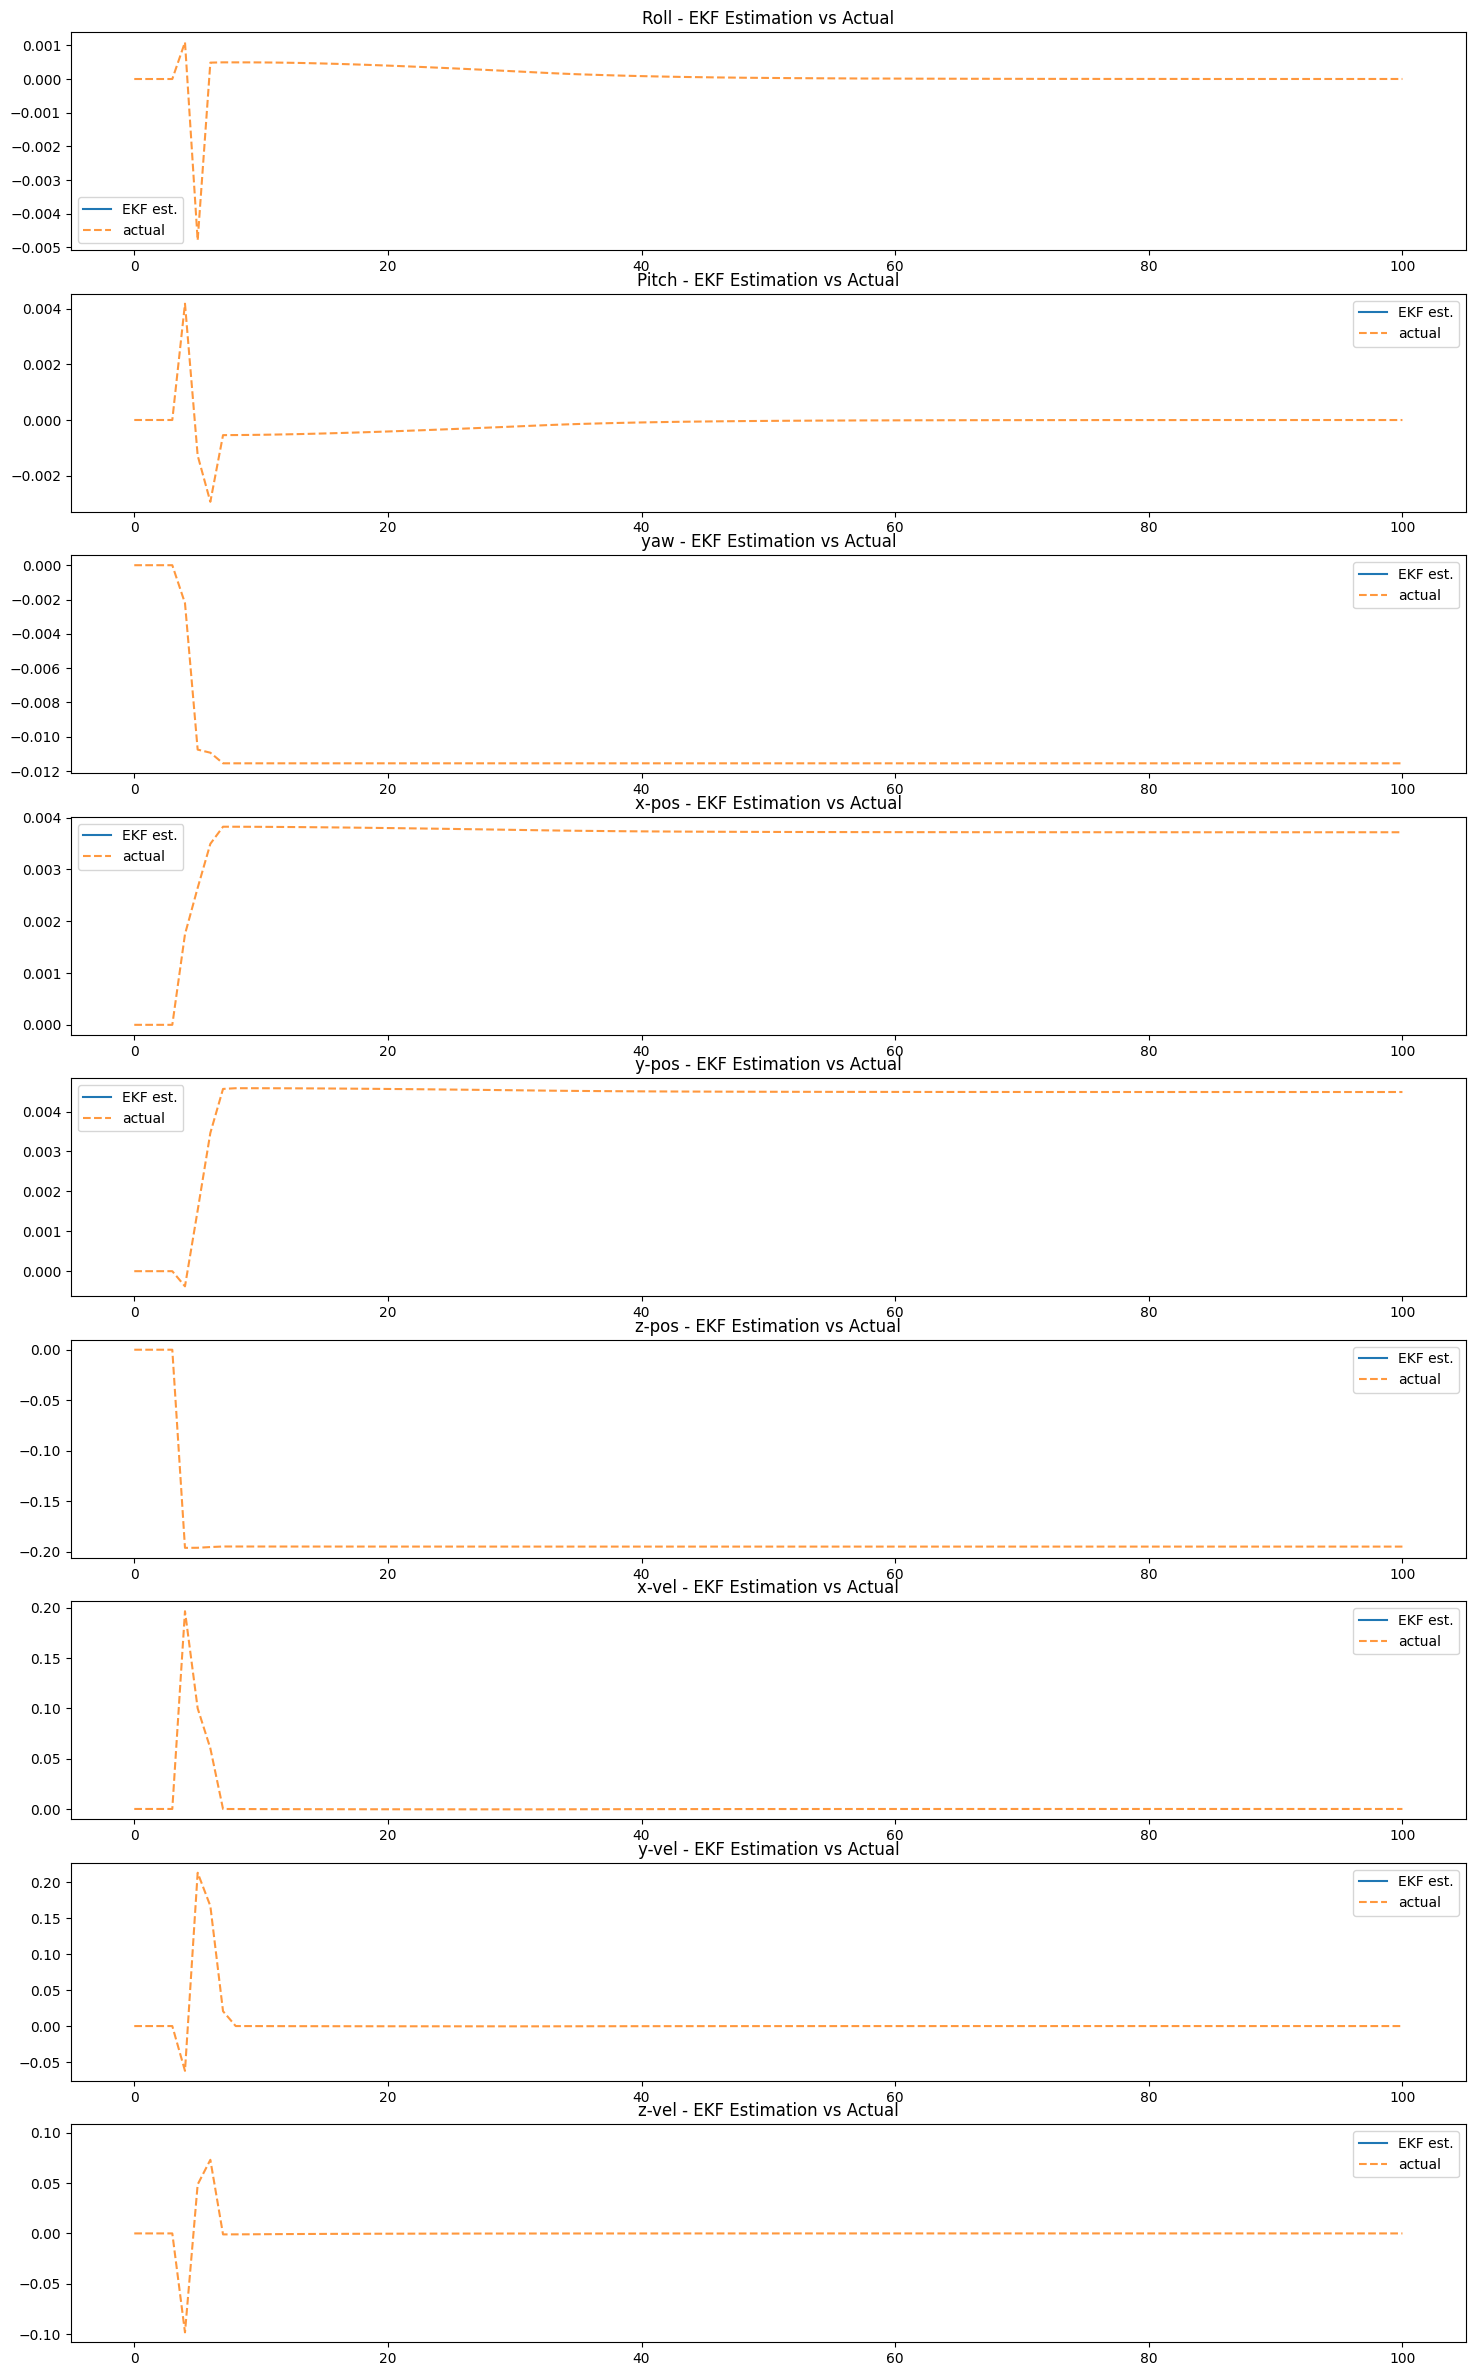

In [8]:
ekf_plot = {}

## Run full EKF estimation with provided variances for sensor estimation
ekf_vals = run_full_ekf({
    'avar': 0.001**2,
    'gvar': 0.001**2,
    'mvar': 100**2,
    'gps_pvar': 10,
    'gps_vvar': 10,
    'baro_var': 0.1,
    'q_drift_var': 0.01,
    'a_drift_var': 0.01},
{'fuse_acc': False,
    'fuse_mag': False,
    'fuse_gps': False,
    'fuse_baro': False})

fig, ax = plt.subplots(9,1, figsize=(18,30))


#roll_integrated = np.zeros((len(mc_y['roll'])-100,))
#for i in range(0,roll_integrated.shape[0]-1):
#    roll_integrated[i+1] = roll_integrated[i] + mc_y['gyro_x'][i]*0.01

ax[0].plot(range(0,len(ekf_vals['ekf_state'][0])), ekf_vals['ekf_state'][0], label='EKF est.')
ax[0].plot(range(0,len(mc_y['eul_x_a'])), mc_y['eul_x_a'], label='actual', linestyle='--', alpha=0.8)
#ax[0].plot(roll_integrated, color='purple')
ax[0].set_title("Roll - EKF Estimation vs Actual")
ax[0].legend()

ax[1].plot(range(0,len(ekf_vals['ekf_state'][1])), ekf_vals['ekf_state'][1], label='EKF est.')
ax[1].plot(range(0,len(mc_y['eul_y_a'])), mc_y['eul_y_a'], label='actual', linestyle='--', alpha=0.8)
ax[1].set_title("Pitch - EKF Estimation vs Actual")
ax[1].legend()

ax[2].plot(range(0,len(ekf_vals['ekf_state'][2])), ekf_vals['ekf_state'][2], label='EKF est.')
ax[2].plot(range(0,len(mc_y['eul_z_a'])), mc_y['eul_z_a'], label='actual', linestyle='--', alpha=0.8)
ax[2].set_title("yaw - EKF Estimation vs Actual")
ax[2].legend()

ax[3].plot(range(0,len(ekf_vals['ekf_state'][3])), ekf_vals['ekf_state'][3], label='EKF est.')
ax[3].plot(range(0,len(mc_y['pos_x_a'])), mc_y['pos_x_a'], label='actual', linestyle='--', alpha=0.8)
ax[3].set_title("x-pos - EKF Estimation vs Actual")
ax[3].legend()

ax[4].plot(range(0,len(ekf_vals['ekf_state'][4])), ekf_vals['ekf_state'][4], label='EKF est.')
ax[4].plot(range(0,len(mc_y['pos_y_a'])), mc_y['pos_y_a'], label='actual', linestyle='--', alpha=0.8)
ax[4].set_title("y-pos - EKF Estimation vs Actual")
#ax[4].set_ylim(-10, 10)
ax[4].legend()

ax[5].plot(range(0,len(ekf_vals['ekf_state'][5])), ekf_vals['ekf_state'][5], label='EKF est.')
ax[5].plot(range(0,len(mc_y['pos_z_a'])), mc_y['pos_z_a'], label='actual', linestyle='--', alpha=0.8)
ax[5].set_title("z-pos - EKF Estimation vs Actual")
ax[5].legend()

ax[6].plot(range(0,len(ekf_vals['ekf_state'][6])), ekf_vals['ekf_state'][6], label='EKF est.')
ax[6].plot(range(0,len(mc_y['vel_x_a'])), mc_y['vel_x_a'], label='actual', linestyle='--', alpha=0.8)
ax[6].set_title("x-vel - EKF Estimation vs Actual")
ax[6].legend()

ax[7].plot(range(0,len(ekf_vals['ekf_state'][7])), ekf_vals['ekf_state'][7], label='EKF est.')
ax[7].plot(range(0,len(mc_y['vel_y_a'])), mc_y['vel_y_a'], label='actual', linestyle='--', alpha=0.8)
ax[7].set_title("y-vel - EKF Estimation vs Actual")
ax[7].legend()

ax[8].plot(range(0,len(ekf_vals['ekf_state'][8])), ekf_vals['ekf_state'][8], label='EKF est.')
ax[8].plot(range(0,len(mc_y['vel_z_a'])), mc_y['vel_z_a'], label='actual', linestyle='--', alpha=0.8)
ax[8].set_title("z-vel - EKF Estimation vs Actual")
ax[8].legend()

plt.show()

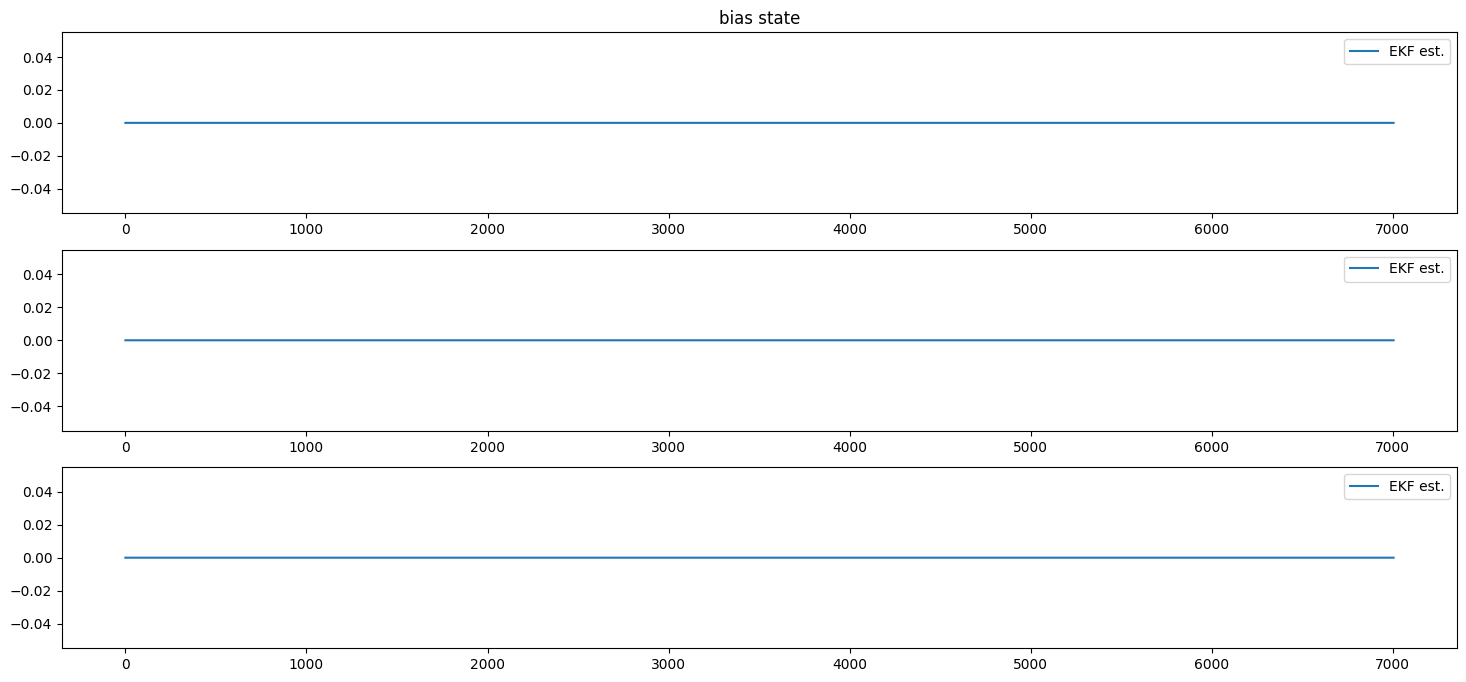

In [10]:
fig, ax = plt.subplots(3,1, figsize=(18,8))

ax[0].plot(range(0,len(ekf_vals['ekf_state'][9])), ekf_vals['ekf_state'][9], label='EKF est.')
ax[0].set_title('bias state')
ax[0].legend()

ax[1].plot(range(0,len(ekf_vals['ekf_state'][10])), ekf_vals['ekf_state'][10], label='EKF est.')
ax[1].legend()

ax[2].plot(range(0,len(ekf_vals['ekf_state'][11])), ekf_vals['ekf_state'][11], label='EKF est.')
ax[2].legend()

plt.show()

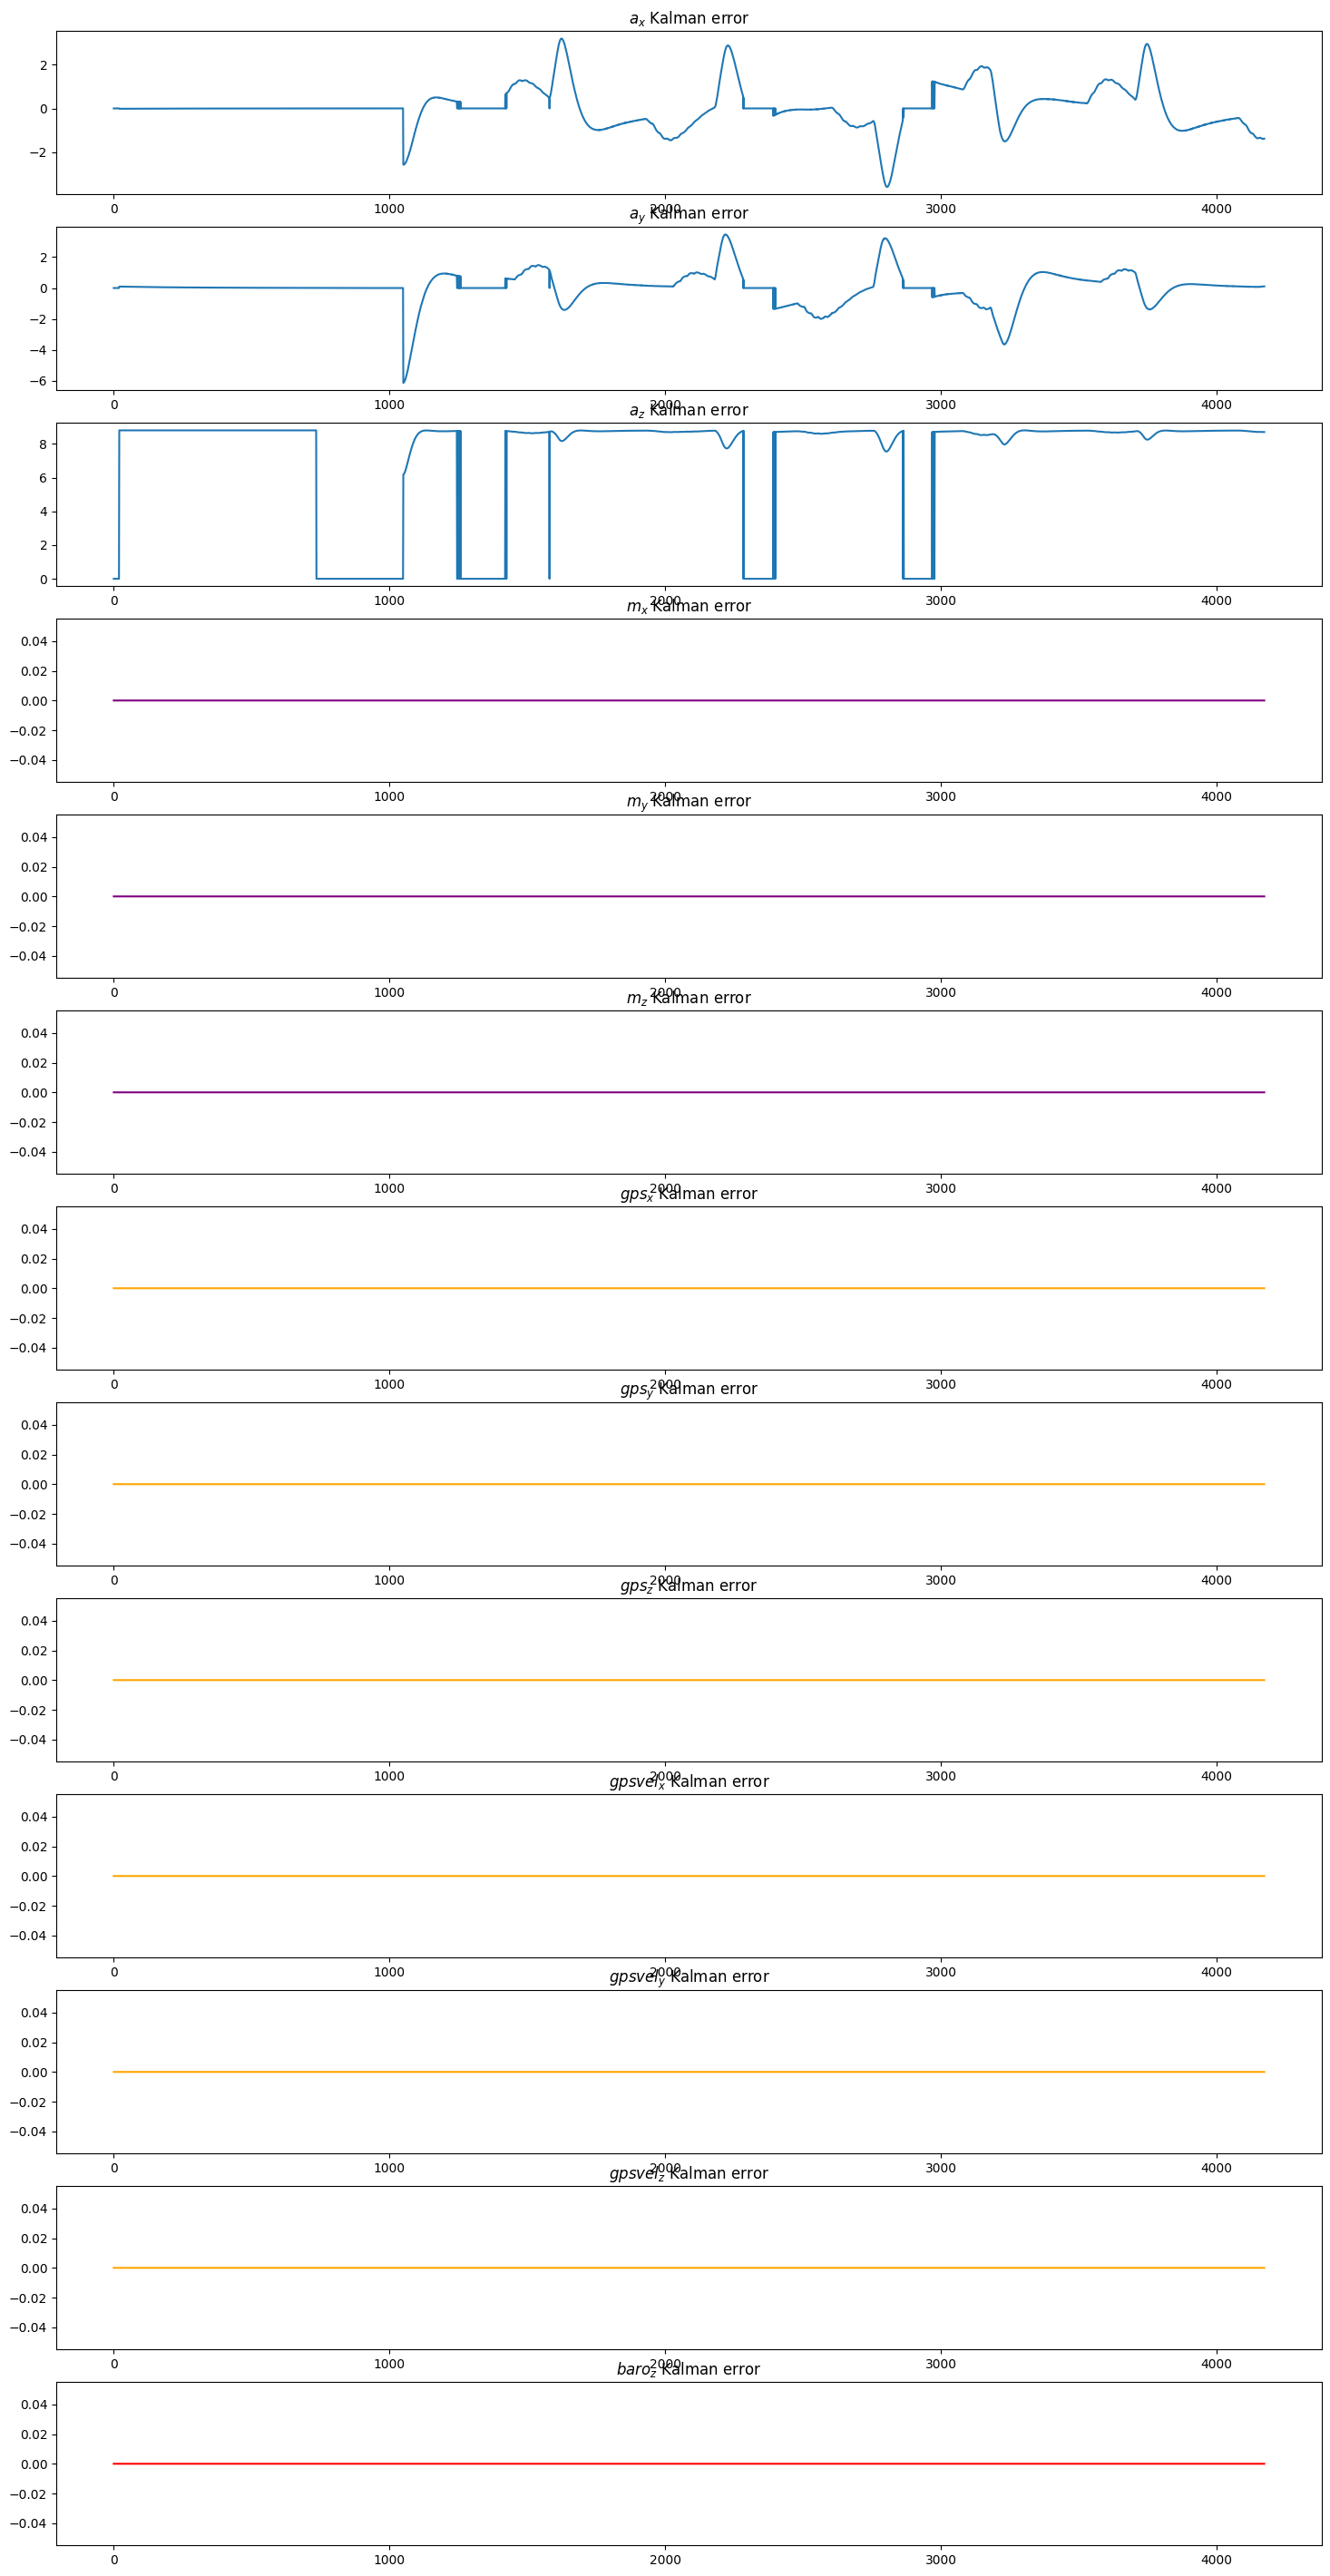

In [60]:
## Kalman Gain and Error plots
fig, ax = plt.subplots(13,1,figsize=(18,36))

x_length = ekf_vals['ekf_vt_acc'].shape[1]

ax[0].plot(range(0,x_length), ekf_vals['ekf_vt_acc'][0,:])
ax[0].set_title(r"$a_{x}$ Kalman error")
ax[1].plot(range(0,x_length), ekf_vals['ekf_vt_acc'][1,:])
ax[1].set_title(r"$a_{y}$ Kalman error")
ax[2].plot(range(0,x_length), ekf_vals['ekf_vt_acc'][2,:])
ax[2].set_title(r"$a_{z}$ Kalman error")

ax[3].plot(range(0,x_length), ekf_vals['ekf_vt_mag'][0,:], color='purple')
ax[3].set_title(r"$m_{x}$ Kalman error")
ax[4].plot(range(0,x_length), ekf_vals['ekf_vt_mag'][1,:], color='purple')
ax[4].set_title(r"$m_{y}$ Kalman error")
ax[5].plot(range(0,x_length), ekf_vals['ekf_vt_mag'][2,:], color='purple')
ax[5].set_title(r"$m_{z}$ Kalman error")

ax[6].plot(range(0,x_length), ekf_vals['ekf_vt_gps'][0,:], color='orange')
ax[6].set_title(r"$gps_{x}$ Kalman error")
ax[7].plot(range(0,x_length), ekf_vals['ekf_vt_gps'][1,:], color='orange')
ax[7].set_title(r"$gps_{y}$ Kalman error")
ax[8].plot(range(0,x_length), ekf_vals['ekf_vt_gps'][2,:], color='orange')
ax[8].set_title(r"$gps_{z}$ Kalman error")
ax[9].plot(range(0,x_length), ekf_vals['ekf_vt_gps'][3,:], color='orange')
ax[9].set_title(r"$gpsvel_{x}$ Kalman error")
ax[10].plot(range(0,x_length), ekf_vals['ekf_vt_gps'][4,:], color='orange')
ax[10].set_title(r"$gpsvel_{y}$ Kalman error")
ax[11].plot(range(0,x_length), ekf_vals['ekf_vt_gps'][5,:], color='orange')
ax[11].set_title(r"$gpsvel_{z}$ Kalman error")

ax[12].plot(range(0,x_length), ekf_vals['ekf_vt_baro'][0,:], color='red')
ax[12].set_title(r"$baro_{z}$ Kalman error")

plt.show()

## Covariances

(16, 16, 4173)


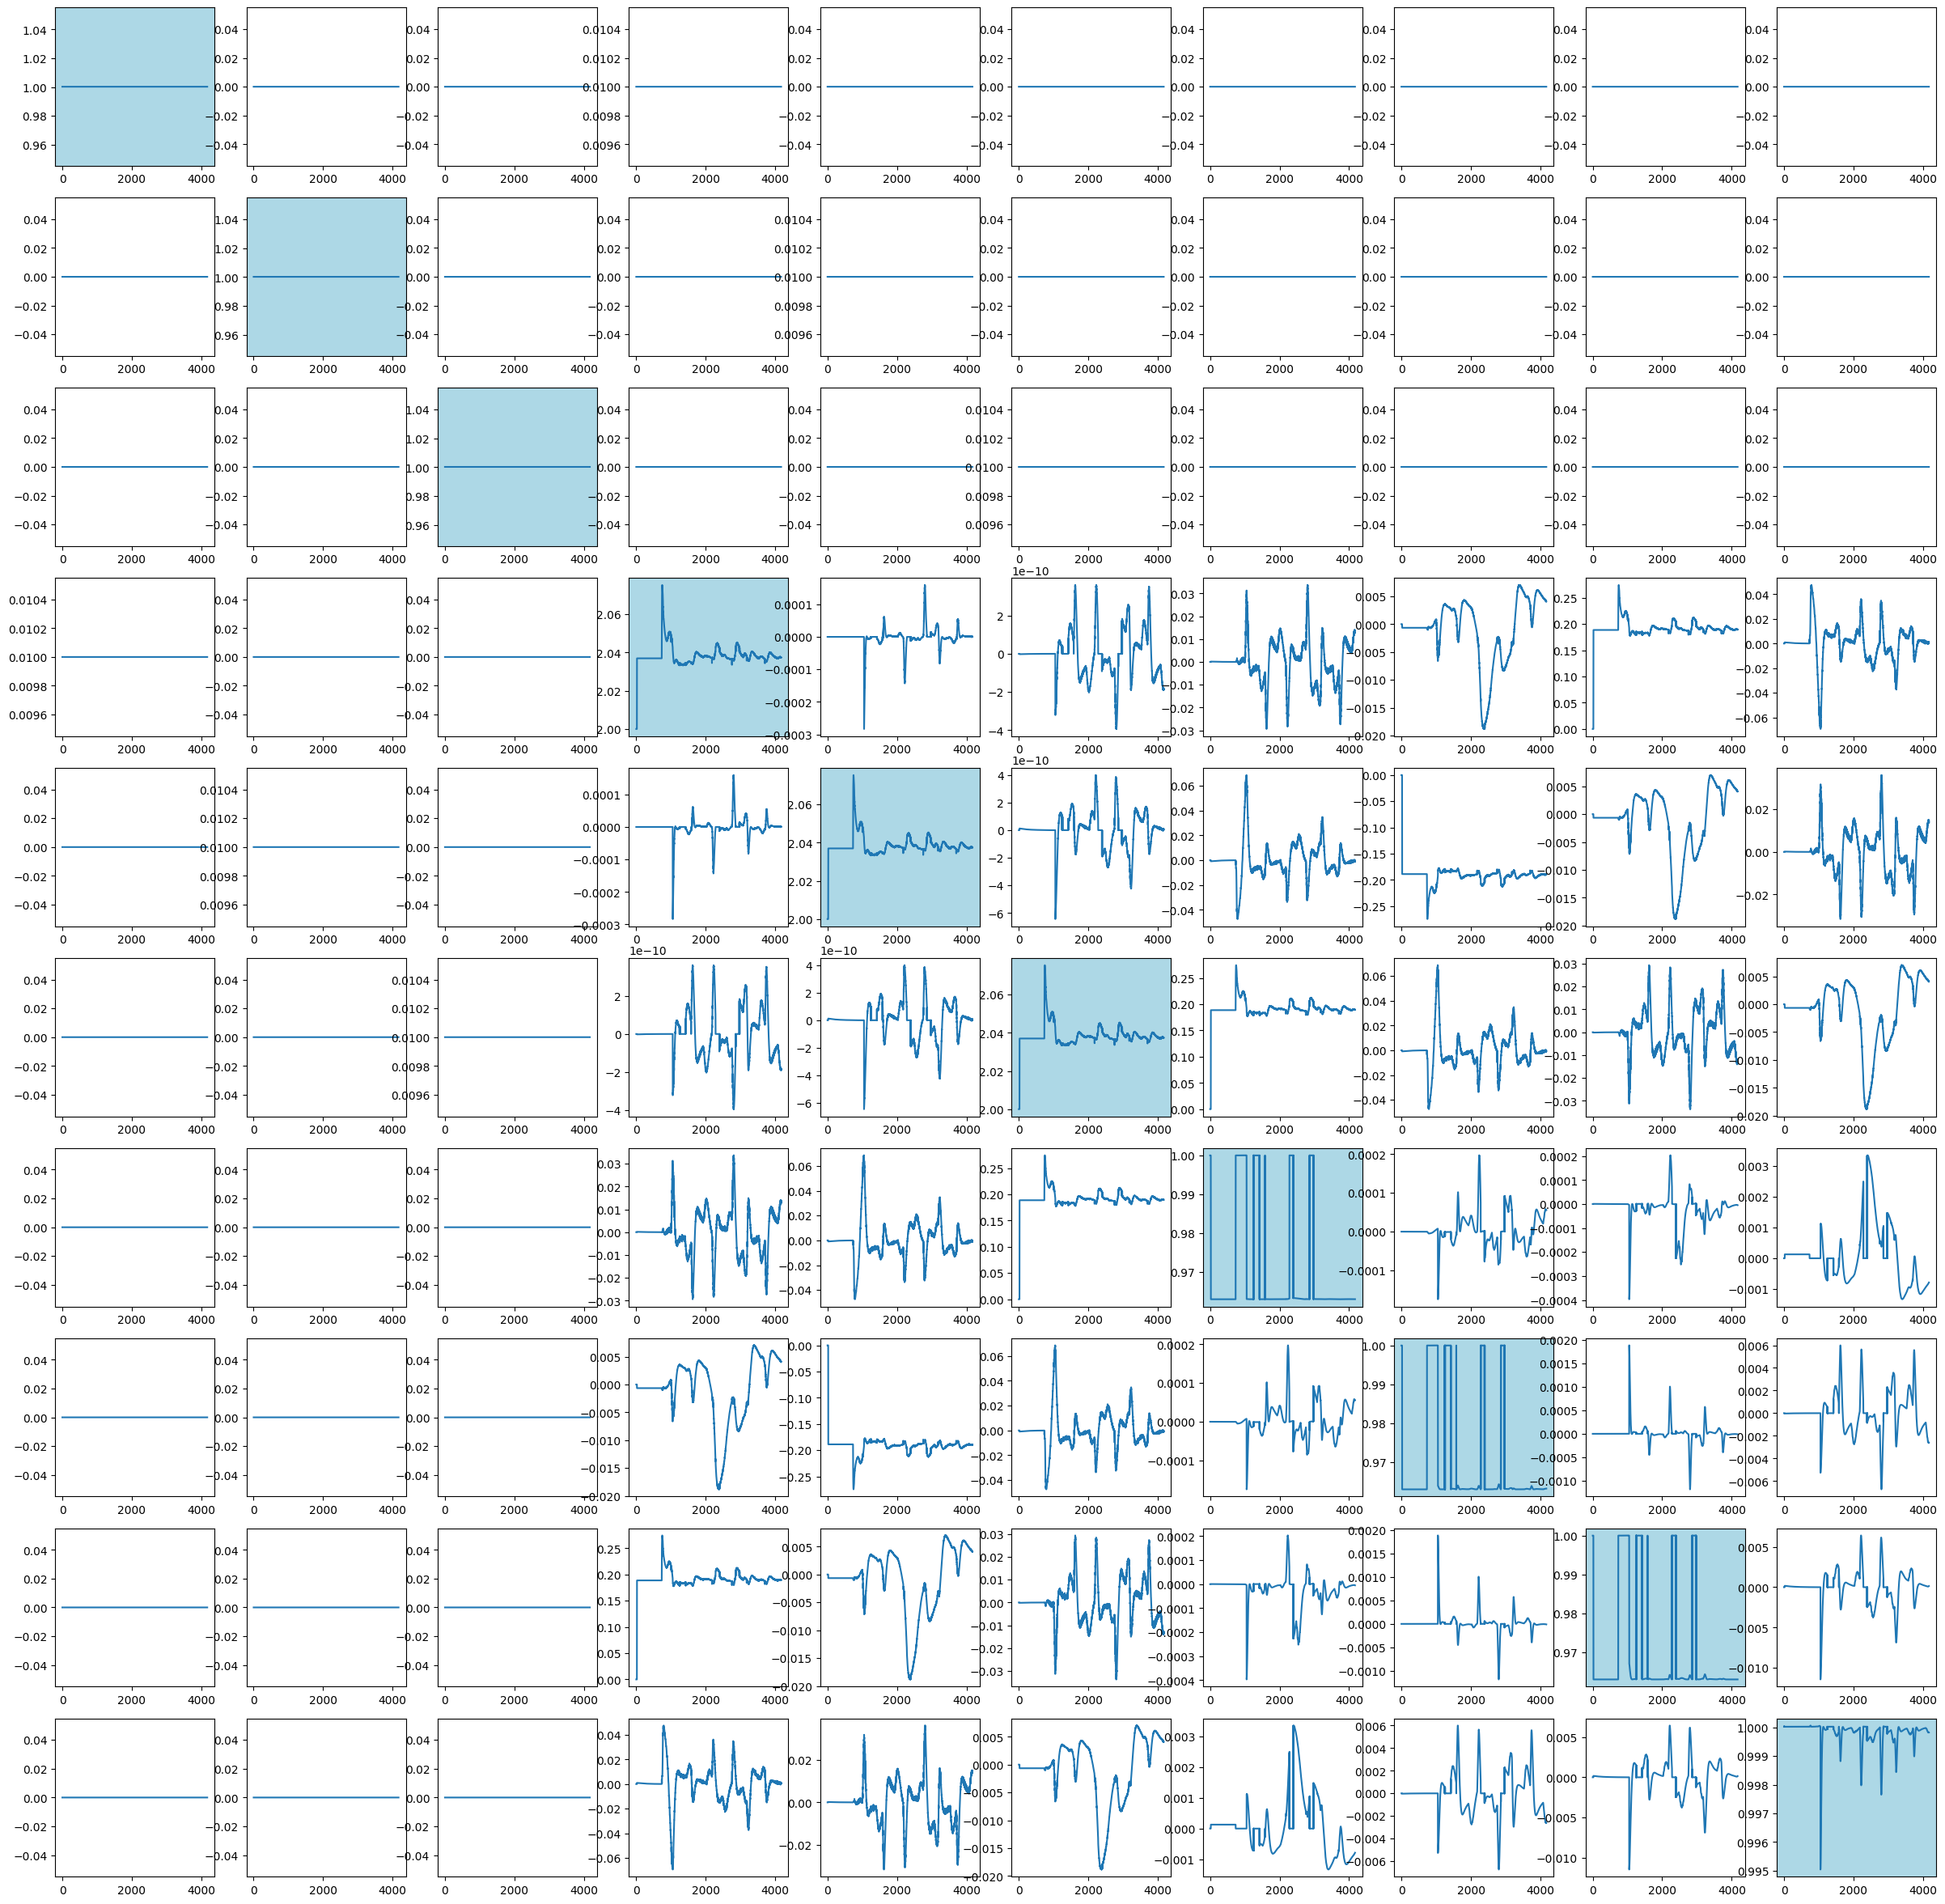

In [58]:
print(ekf_vals['ekf_cov'].shape)

fig, ax = plt.subplots(10,10, figsize=(30,30))

for i in range(0,10):
    for j in range(0,10):
        ax[i,j].plot(ekf_vals['ekf_cov'][i,j,:])
        if i==j:
            ax[i,j].set_facecolor('lightblue')

plt.show()

## Accelerometer Norm plot

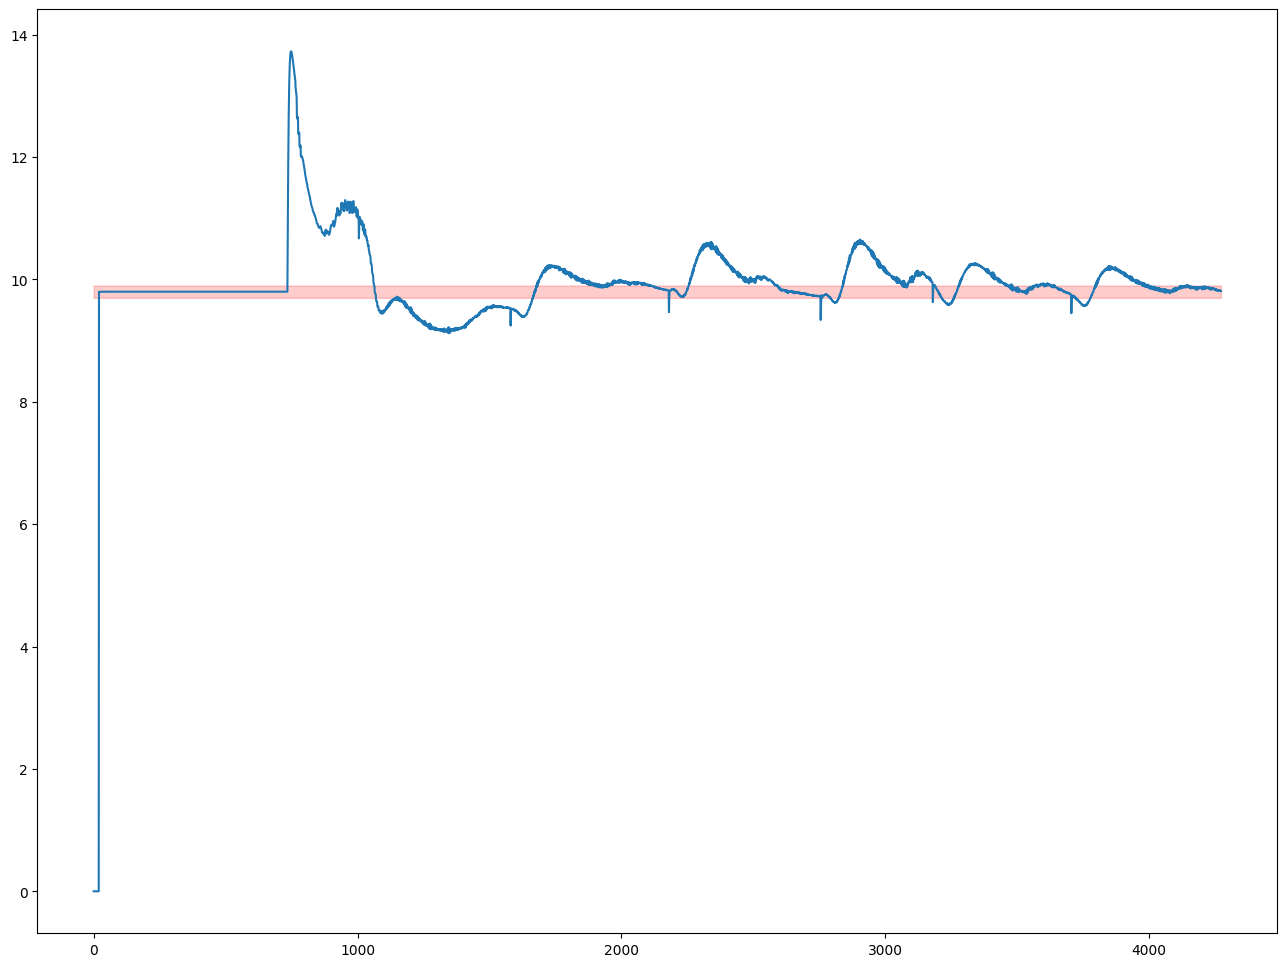

In [19]:
xlen = len(mc_y['accel_x'])

anorm = [math.sqrt(mc_y['accel_x'][i]**2 + mc_y['accel_y'][i]**2 + mc_y['accel_z'][i]**2) for i in range(0,xlen)]

fig, ax = plt.subplots(1,1,figsize=(16,12))

ax.plot(anorm)
tol = 0.1
ax.fill_between(range(0,xlen), xlen*[9.8+tol], xlen*[9.8-tol], alpha=0.2, color='red')
plt.show()